In [1]:
import pandas as pd
data = pd.read_csv("../data/data_preprossing.csv")
data.shape

(652, 13)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

X = data.drop(["List Price", "IPO_Name", "Date"] ,axis = 1)
y = data["List Price"]

X_train,X_test,y_train,y_test = train_test_split(X,y , test_size = 0.20 , random_state = 1)
model = RandomForestRegressor()

params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [1.0, "sqrt", "log2"]
}

random_rf_search = RandomizedSearchCV(
    estimator = model ,
    param_distributions = params , 
    n_iter = 20 , 
    cv = 5 ,
    scoring = "r2" ,
    n_jobs = -1 ,
    random_state = 1)


random_rf_search.fit(X_train ,y_train)
print(random_rf_search.best_params_)
print(random_rf_search.best_score_)

{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 20}
RandomForestRegressor(max_depth=20)
0.9560603747345789


In [10]:
best_rf_model = random_rf_search.best_estimator_
y_rf_pred = best_rf_model.predict(X_test)
print(y_rf_pred[:10])

[ 14.1455  61.3315  60.6061 107.5885 695.01   139.734  254.2525 545.473
 764.698  219.354 ]


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_rf_pred)))
print("R2:", r2_score(y_test, y_rf_pred))

MAE: 25.902006106870243
RMSE: 70.21062067231641
R2: 0.9725800744561459


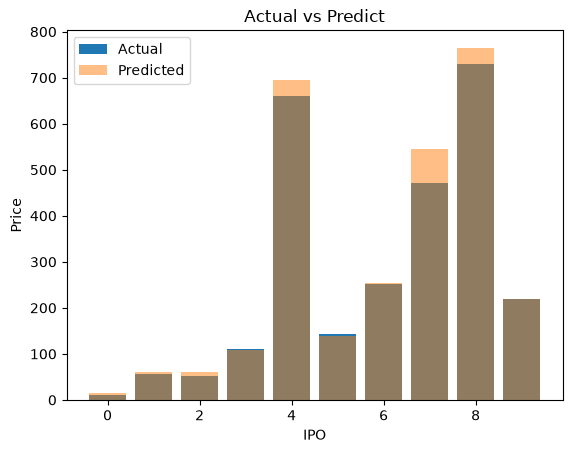

In [14]:
import matplotlib.pyplot as plt

plt.Figure(figsize=(10,6))

plt.bar(range(10), y_test[:10], label="Actual")
plt.bar(range(10), y_rf_pred[:10], alpha=0.5, label="Predicted")

plt.xlabel("IPO")
plt.ylabel("Price")
plt.title("Actual vs Predict")
plt.legend()

plt.show()